Hier komen de imports

In [74]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

Vraag 1
Iemand wil een LDA model maken om de *price_range* van een gsm te voorspellen. Hij gebruikt daarvoor 8 onafhankelijke variabelen. Hoeveel lineaire discriminant functies zal zijn model bevatten? *We vragen dus niet om een model te maken, maar enkel om het aantal lineaire discriminant functies te bepalen.*

In [4]:
#de berekening is als volgt 
# K (klassen) - 1 --> 4 - 1 --> uitkomst is 3 lineaire discriminant functies

# Vraag 2
## a. (1 punt) 
Maak nu zelf een LDA model waarbij je op basis van *battery_power*, *clock_speed*, *fc*, *int_memory*, *n_cores*, *pc*, *ram* en *talk_time* tracht te voorspellen of de prijs van de gsm in de hoogste klasse zit. De afhankelijke variabele is dus niet gewoon price_range maar heeft als waarde True indien *price_range* == 3.

In [11]:
#eerst csv inladen 
df_phones = pd.read_csv("CellPhone_train.csv", sep=",", date_format=".")

In [13]:
#optioneel als we unwanted data willen verijderen 
df_phones.dropna()

,Unnamed: 0.1,Unnamed: 0,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,...,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range,predicted_price_range,predicted_price_range_proba
0,0,0,842,0,2.2,0,1,0,7,0.6,...,2549,9,7,19,0,0,1,1,2,0.228768
1,1,1,1021,1,0.5,1,0,1,53,0.7,...,2631,17,3,7,1,1,0,2,2,0.219890
2,2,2,563,1,0.5,1,2,1,41,0.9,...,2603,11,2,9,1,1,0,2,2,0.245067
3,3,3,615,1,2.5,0,0,0,10,0.8,...,2769,16,8,11,1,0,0,2,2,0.177855
4,4,4,1821,1,1.2,0,13,1,44,0.6,...,1411,8,2,15,1,1,0,1,1,0.400540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1995,1995,794,1,0.5,1,0,1,2,0.8,...,668,13,4,19,1,1,0,0,0,0.471320
1996,1996,1996,1965,1,2.6,1,0,0,39,0.2,...,2032,11,10,16,1,1,1,2,2,0.207789
1997,1997,1997,1911,0,0.9,1,1,1,36,0.7,...,3057,9,1,5,1,1,0,3,3,0.127551
1998,1998,1998,1512,0,0.9,0,4,1,46,0.1,...,869,18,10,19,1,1,1,0,0,0.360317


In [18]:
#BELANGRIJK --> data preparation 
y = (df_phones['price_range'] == 3).astype(int)
X = df_phones[['battery_power', 'clock_speed', 'fc', 'int_memory', 'n_cores', 'pc', 'ram', 'talk_time']]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [24]:
#LDA trainen plus evaluaten 
#LDA schalen en trainen tegelijkertijd 
lda = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis())
lda.fit(X_train, y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('lineardiscriminantanalysis', LinearDiscriminantAnalysis())])

In [25]:
#EVALUATIE
y_pred = lda.predict(X_test)
y_proba = lda.predict_proba(X_test)[:, 1]

In [26]:
#FEEDBACK returnen naar user
print("Accuracy :", accuracy_score(y_test, y_pred))
print("AUC      :", roc_auc_score(y_test, y_proba))
print("Confusion:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

Accuracy : 0.93
AUC      : 0.9829
Confusion:
 [[281  19]
 [  9  91]]
              precision    recall  f1-score   support

           0      0.969     0.937     0.953       300
           1      0.827     0.910     0.867       100

    accuracy                          0.930       400
   macro avg      0.898     0.923     0.910       400
weighted avg      0.934     0.930     0.931       400



### b. (1 punt)
Wat zijn de coëfficiënten van de eerste discriminant functie? 

In [28]:
lda = LinearDiscriminantAnalysis().fit(X, y)

coef_lda1 = pd.Series(lda.scalings_[:, 0], index=X.columns)
print(coef_lda1)

battery_power    0.000855
clock_speed     -0.015213
fc              -0.010454
int_memory       0.004280
n_cores         -0.001439
pc               0.003935
ram              0.001301
talk_time       -0.003131
dtype: float64


# Vraag 3
In de kolom *predicted_price_range* vind je de voorspelde *price_range* waarden van een AI model (waarover we verder niet in detail gaan).

## a. (1,5 punten)
Bereken *precision*, *recall*, en *F1-score* voor elke klasse.

In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

y = df_phones['price_range'].astype(int)
y_pred_price = df_phones['predicted_price_range'].astype(int)

# Per klasse
prec = precision_score(y, y_pred_price, average=None)
rec  = recall_score(y, y_pred_price, average=None)
f1   = f1_score(y, y_pred_price, average=None)

print("Precision per klasse:", prec)
print("Recall per klasse   :", rec)
print("F1-score per klasse :", f1)

# Of in mooi tabel formaat
print("\n", classification_report(y, y_pred_price, digits=3))

Precision per klasse: [0.89514563 0.77505112 0.73727088 0.86732673]
Recall per klasse   : [0.922 0.758 0.724 0.876]
F1-score per klasse : [0.90837438 0.76643074 0.73057518 0.87164179]

               precision    recall  f1-score   support

           0      0.895     0.922     0.908       500
           1      0.775     0.758     0.766       500
           2      0.737     0.724     0.731       500
           3      0.867     0.876     0.872       500

    accuracy                          0.820      2000
   macro avg      0.819     0.820     0.819      2000
weighted avg      0.819     0.820     0.819      2000



## b. (1,5 punten)
Voor welke klasse is het model het best in staat een voorspelling te doen? Op basis van welke informatie heb je dit beslist?



Het model voorspelt **klasse 0** het best.  
Dit besluit is gebaseerd op de evaluatiemetrics:

- **F1-score**: Klasse 0 heeft de hoogste F1-score (0.908) van alle klassen.  
  De F1-score is de harmonische gemiddelde van precision en recall, en geeft dus een gebalanceerde maat voor prestaties.
- **Precision**: Met 0.895 is de kans dat een voorspelde klasse 0 ook werkelijk klasse 0 is, zeer hoog.
- **Recall**: Met 0.922 herkent het model 92,2% van alle werkelijke klasse 0-items correct.
- In vergelijking met de andere klassen zijn zowel precision, recall als F1-score bij klasse 0 het hoogst, wat erop wijst dat het model hier het meest accuraat en betrouwbaar is.


# Vraag 4
### a. (1 punt)
In een ander getraind AI-model hebben we onze focus gelegd op de gsm's in de middelste prijsklasse. We trachten in dit model te voorspellen of een gsm al dan niet in de prijsklasse 1 zit. De werkelijke waarde van de afhankelijke variabele is met andere woorden *price_range* == 1.

In de kolom *predicted_price_range_proba* vind je de voorspelde kansen dat een gsm in die middelste prijsklasse zit volgens het model.

Gebruik deze kolom om op basis van deze voorspelde kansen een ROC curve te tekenen. Wat is de AUC? 

de ROC‐curve laat je zien bij welke drempels je classifier een goede balans vindt tussen het vinden van positieve gevallen (TPR) en het vermijden van valse alarmen (FPR). De AUC geeft in één getal aan hoe goed dat in het algemeen lukt.

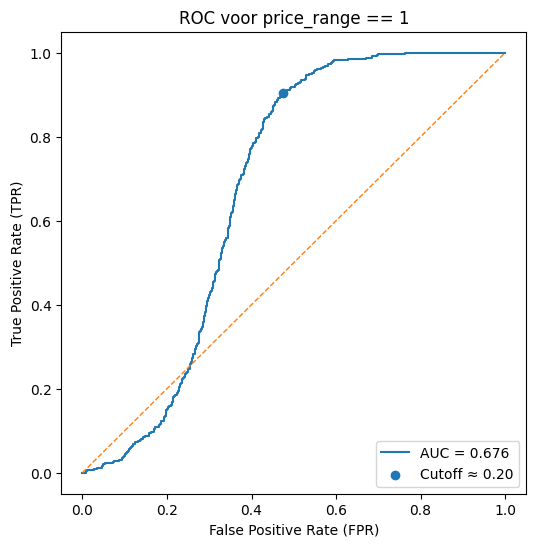

AUC = 0.676
Optimale drempel (Youden) ≈ 0.205


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc_from_df(df, y_col='price_range', proba_col='predicted_price_range_proba',
                     pos_class=1, title='ROC voor price_range == 1'):
    """
    - df[y_col]: echte labels (0..K-1). We nemen pos_class als positief.
    - df[proba_col]: kans op pos_class (float tussen 0 en 1).
    Returns dict met fpr, tpr, thresholds, auc, optimal_threshold.
    """
    # 1) y en score klaarzetten
    y_true = (df[y_col] == pos_class).astype(int).to_numpy()
    y_score = df[proba_col].astype(float).to_numpy()

    # 2) ROC + AUC
    fpr, tpr, thr = roc_curve(y_true, y_score, pos_label=1)
    auc = roc_auc_score(y_true, y_score)

    # 3) Beste drempel (Youden J)
    j = tpr - fpr
    j_idx = np.argmax(j)
    opt_thr = thr[j_idx]

    # 4) Plot
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
    ax.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
    ax.scatter(fpr[j_idx], tpr[j_idx], label=f'Cutoff ≈ {opt_thr:.2f}', zorder=3)
    ax.set_title(title)
    ax.set_xlabel('False Positive Rate (FPR)')
    ax.set_ylabel('True Positive Rate (TPR)')
    ax.legend(loc='lower right')
    plt.show()

    return {
        'fpr': fpr, 'tpr': tpr, 'thresholds': thr,
        'auc': auc, 'optimal_threshold': opt_thr
    }

# --- Gebruik:
res = plot_roc_from_df(df_phones,
                       y_col='price_range',
                       proba_col='predicted_price_range_proba',
                       pos_class=1)

print(f"AUC = {res['auc']:.3f}")
print(f"Optimale drempel (Youden) ≈ {res['optimal_threshold']:.3f}")


## b. (1 punt)
Wat is het optimal cutoff point voor deze ROC curve? Wat wil dit zeggen? 


Bij een cutoff van 0.205 label je alle voorbeelden met
  
0.205
p(prijsrange=1)>0.205
als “middelkost” (positief) en de rest als “niet middelkost” (negatief).
Betekenis:
Je vangt 90.4 % (TPR) van de echte middelkost-gsm’s op,
terwijl je 47.4 % (FPR) van de niet-middelkost-gsm’s ten onrechte als positief markeert.
Deze drempel maximaliseert het verschil TPR − FPR (Youden’s J = 0.430), dus geeft de beste balans tussen sensitiviteit en specificiteit.

AUC = Area Under the Curve van de ROC-grafiek.
Die geeft globaal aan hoe goed het model presteert over alle mogelijke thresholds.
Waarde tussen 0.5 (slecht model) en 1.0 (perfect model).
Dus: AUC is een score, géén drempelwaarde!

🔷 Wat is de optimal cutoff point?
De één enkele drempelwaarde waarbij het model de beste balans vindt tussen TPR en FPR.
Die bereken je met bijv. Youden's J-statistiek:
Die cutoff is een threshold (bv. 0.205), niet hetzelfde als AUC.


# Vraag 5

a. Hoeveel inputvariabelen heeft dit netwerk? --> 3 inputvariabelen

b. Hoeveel categorieën heeft de onafhankelijke (te voorspellen) variabele? --> 2 outputnodes dus --> 2 categories

c. Welke node uit de hidden layer heeft de grootste invloed op node 2 van de output layer? Geef de naam die boven de node staat. --> H1

d. In de nodes zie je een schematische weergave van de activatiefunctie. Welke activatiefunctie wordt hier gebruikt? --> sigmoid


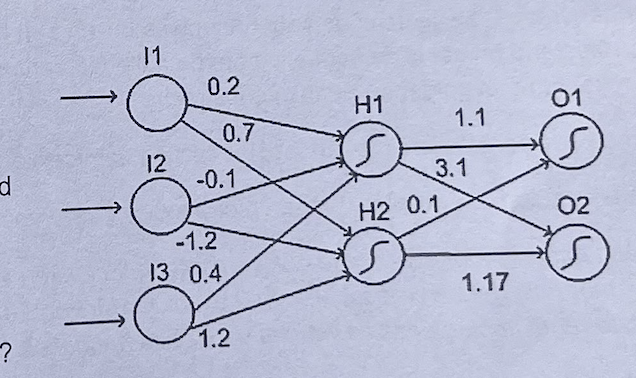

# Vraag 6 (3 punten)
Train een neuraal netwerk met volgende specificaties:
* De inputlayer heeft een ode voor elk van de volgende variabelen:
    * *battery_power*
    * *clock_speed*
    * *fc*
    * *int_memory*
    * *n_cores*
    * *pc*
    * *ram*
    * *talk_time*
* De afhankelijke variabele (Y) is *price_range*
* Pas BatchNormalization toe op de inputlayer om de data te normaliseren.
* De (enige) hidden layer heeft 8 nodes en gebruikt de ReLU activatiefunctie.
* De outputlayer heeft 4 nodes voor elke categorie van *price_range* en gebruikt de softmax activatiefunctie.
* Gebruik ```model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.10), loss=keras.losses.categorical_crossentropy, metrics=['accuracy'])``` om het model te compileren.
* Train het model gedurende 10 epochs met een batch_size van 32 en een validation_split van 0.2. We moeten in de output kunnen zien dat het model getraind werd.

In [109]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input, Dense, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

# 1. Data inlezen en splitsen
X = df_phones[['battery_power','clock_speed','fc','int_memory',
          'n_cores','pc','ram','talk_time']]
y = df_phones['price_range']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# 2. One-hot encoding van de target volgens softmax vereiste
y_train_oh = to_categorical(y_train)  # shape (n_samples, 4)
y_test_oh  = to_categorical(y_test)

# 3. Modeldefinitie: Input → BatchNorm → Hidden(ReLU) → Output(softmax)
inputs = Input(shape=(8,))                       # 8 inputfeatures
norm   = BatchNormalization()(inputs)            # normaliseer input
hidden = Dense(8, activation='relu')(norm)       # 8 neuronen met ReLU
outputs = Dense(4, activation='softmax')(hidden) # 4 klassen, softmax

model = Model(inputs=inputs, outputs=outputs, name='price_range_NN')

# 4. Model compileren met Adam en categorical_crossentropy
model.compile(
    optimizer=Adam(learning_rate=0.10),           
    loss=CategoricalCrossentropy(),               
    metrics=['accuracy']
)

# 5. Trainen: 10 epochs, batch_size=32, validation_split=0.2
history = model.fit(
    X_train, y_train_oh,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# (optioneel) Evaluatie op testset
# loss, acc = model.evaluate(X_test, y_test_oh)
# print(f"Test accuracy: {acc:.3f}")

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4506 - loss: 1.1378 - val_accuracy: 0.2344 - val_loss: 12.6932
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6803 - loss: 0.6774 - val_accuracy: 0.2750 - val_loss: 3.5529
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7597 - loss: 0.5642 - val_accuracy: 0.4031 - val_loss: 1.5629
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7661 - loss: 0.5396 - val_accuracy: 0.4656 - val_loss: 1.4419
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7546 - loss: 0.5415 - val_accuracy: 0.7063 - val_loss: 0.6874
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7670 - loss: 0.5621 - val_accuracy: 0.8500 - val_loss: 0.4177
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7248 - loss: 0.6214 - val_accuracy: 0.8344 - val_loss: 0.4135
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7376 - loss: 0.5567 - val_accuracy: 0.8125 - val_loss

# Vraag 7 (2 punten)
In de code onder de vraag zie je 10 chromosomen. Ook de doelfunctie waarvan we het resultaat willen maximaliseren is gegeven. Welke van deze oplossingen zal volgens het roulette selectiemechanisme het meeste kans maken om geselcteerd te worden voor mating/paring? Waarom?  

In [110]:
import math

x1 = [1.0, 0.5]
x2 = [-0.5, -0.5]
x3 = [1.0, 1.0]
x4 = [-0.75, -0.75]
x5 = [-0.5, 0.0]
x6 = [-0.5, -1.0]
x7 = [0.5, 0.5]
x8 = [0.5, 0.0]
x9 = [0.75, 0.75]
x10 = [-1.2, -1.0]


def energy(x):
    return ((0.2 + x[0] * x[0] + x[0] * x[1] - 0.1 * np.cos(1.0 * math.pi * x[0]) - 0.1 * np.cos(-2.0 * np.pi * x[1])))

In [111]:
energy(x1)
energy(x2)
energy(x3)
energy(x4)
energy(x5)
energy(x6)
energy(x7)
energy(x8)
energy(x9)
energy(x10)

2.8209016994374947

## Antwoord

x10 heeft de meeste kans om geselecteerd te worden voor pairing omdat hij de hoogste energy heeft 2.8209016994374947

# Vraag 8 (2 punten)
In de code bij vraag 8 vind je een dataframe. Deze bevat de scores van de doelfunctie voor een generatie chromosomen. Het optimalisatieprobleem is een minimalisatieprobleem. Voor de selectie van de chromosomen die mogen paren/maten wordt het tournament selectie mechanisme gebruikt.

Voor de eerste selecteren chromosoom werd in de eerste stap van het selectie-algoritme chromosomen 1, 3, 6, 8 en 20 geselecteerd. Welke van deze chromosomen zal in aanmerking komen voor 'mating/paring'? Met andere woorden wat is het resultaat van deze selecte-operatie? Waarom?

In [112]:
populatie = pd.DataFrame({'chromosoon': range(1, 21),
                          'score_doelfunctie': [247.6251629, 214.51757898, 249.13309669, 188.81888775, 104.80883904,
                                                316.12006777, 198.56246032, 465.06055288, 156.80288596, 243.7813792,
                                                185.9045345, 146.50208061, 119.45574293, 364.05258658, 416.80157775,
                                                481.66470259, 412.22107183, 421.06760396, 227.18712982, 229.35077602]})
populatie

,chromosoon,score_doelfunctie
0,1,247.625163
1,2,214.517579
2,3,249.133097
3,4,188.818888
4,5,104.808839
5,6,316.120068
6,7,198.562460
7,8,465.060553
8,9,156.802886
9,10,243.781379


#ANTWOORD

Van de selected chromosonen op basis van het minimalisatieprobleem zal tussen de chromosonen 1, 3, 6, 8 en 20 zal 20 winnnen met zijn waarde van 229.35 heeft die de laagste.

Wát er wordt gedaan:
Je neemt een klein “toernooi” (hier: chromosomen 1, 3, 6, 8 en 20) en kiest daaruit één winnaar om door te mogen naar de paringspool.
Hoe die winnaar wordt bepaald:
Omdat het probleem een minimalisatie is, wint het chromosoom met de laagste doelfunctiescore.
Wat het resultaat is voor dit toernooi:
– Chromosoom 1 → score 247.63
– Chromosoom 3 → score 249.13
– Chromosoom 6 → score 316.12
– Chromosoom 8 → score 465.06
– Chromosoom 20 → score 229.35
De laagste score is 229.35, dus chromosoom 20 wordt geselecteerd.


# Vraag 9 
Onder vraag 9 zie je de code voor het oplossen van een Sudoku met simulated annealing. Je krijgt een startbestand en het is de bedoeling de nullen te vervangen door de cijfers 1 tot en met 9. Bij het oplossen hou je rekening met volgende Sudoku contraints:
- In elke rij de getallen 1 tot en met 9 exact 1 keer voorkomen.
- In elke kolom de getallen 1 tot en met 9 exact 1 keer voorkomen.
*In een echte Sudoku is je veld ook verdeeld in 9 blokken van 3\*3. In elk blok moet elk getal van 1 tot en met 9 exact 1 keer voorkomen. Deze laatste regel implementeren we niet voor deze heuristiek.*

Bij deze heuristiek lees je eerst een startSituatie van een sudoku in waarbij de in te vullen waarbij de in te vullen waarden gelijk zijn aan 0 (zie csv). Het grootste deel van de code is al uitgewerkt.

- Cel 1: StartSituatie inlezen > leest de sudoku in. Hierin pas je niet aan.
- Cel 2: emptyfields aanmaken > maakt een lijst van de indices van de lege velden. Hierin pas je niets aan.
- Cel 3: Simulated annealing klasse > bevat de klasse Sudoku die de simulated annealing uitvoert.